<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/PostLab_FML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv("weatherAUS.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())



Saving weatherAUS.csv to weatherAUS (1).csv
Dataset loaded successfully!
Shape: (145460, 23)
Columns:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   W

In [4]:
columns = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm",
    "WindSpeed9am",
    "WindSpeed3pm",
    "RainToday",
    "RainTomorrow"
]

df = df[columns].dropna()

print("Shape after cleaning:", df.shape)

df.head()

Shape after cleaning: (123968, 13)


,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,71.0,22.0,1007.7,1007.1,16.9,21.8,20.0,24.0,No,No
1,7.4,25.1,0.0,44.0,25.0,1010.6,1007.8,17.2,24.3,4.0,22.0,No,No
2,12.9,25.7,0.0,38.0,30.0,1007.6,1008.7,21.0,23.2,19.0,26.0,No,No
3,9.2,28.0,0.0,45.0,16.0,1017.6,1012.8,18.1,26.5,11.0,9.0,No,No
4,17.5,32.3,1.0,82.0,33.0,1010.8,1006.0,17.8,29.7,7.0,20.0,No,No


In [5]:
df["RainToday"] = df["RainToday"].map({
    "Yes": 1,
    "No": 0
})

df["RainTomorrow"] = df["RainTomorrow"].map({
    "Yes": 1,
    "No": 0
})

df = df.dropna()

print(df.head())

   MinTemp  MaxTemp  Rainfall  Humidity9am  Humidity3pm  Pressure9am  \
0     13.4     22.9       0.6         71.0         22.0       1007.7   
1      7.4     25.1       0.0         44.0         25.0       1010.6   
2     12.9     25.7       0.0         38.0         30.0       1007.6   
3      9.2     28.0       0.0         45.0         16.0       1017.6   
4     17.5     32.3       1.0         82.0         33.0       1010.8   

   Pressure3pm  Temp9am  Temp3pm  WindSpeed9am  WindSpeed3pm  RainToday  \
0       1007.1     16.9     21.8          20.0          24.0          0   
1       1007.8     17.2     24.3           4.0          22.0          0   
2       1008.7     21.0     23.2          19.0          26.0          0   
3       1012.8     18.1     26.5          11.0           9.0          0   
4       1006.0     17.8     29.7           7.0          20.0          0   

   RainTomorrow  
0             0  
1             0  
2             0  
3             0  
4             0  


In [6]:
X_class = df.drop("RainTomorrow", axis=1)
y_class = df["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

scaler_class = StandardScaler()

X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)

print("Scaling completed!")

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

Training data: (99174, 12)
Testing data: (24794, 12)
Scaling completed!


In [7]:
classification_results = []

for name, model in classification_models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

classification_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(classification_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8390,0.7050,0.4667,0.5616
1,Decision Tree,0.7783,0.4984,0.5172,0.5077
2,Random Forest,0.8489,0.7368,0.4921,0.5901


In [8]:
cv_classification = []

for name, model in classification_models.items():

    if name == "Logistic Regression":
        X_cv = scaler_class.fit_transform(X_class)
    else:
        X_cv = X_class

    scores = cross_val_score(
        model,
        X_cv,
        y_class,
        cv=5,
        scoring="accuracy"
    )

    cv_classification.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_classification_df = pd.DataFrame(
    cv_classification,
    columns=[
        "Model",
        "CV Mean Accuracy",
        "CV Std"
    ]
)

display(cv_classification_df.round(4))

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.8395,0.0060
1,Decision Tree,0.7663,0.0064
2,Random Forest,0.8433,0.0029


In [11]:
X_reg = df.drop("Rainfall", axis=1)
y_reg = df["Rainfall"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_reg.shape)
print("Testing data:", X_test_reg.shape)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

Training data: (99174, 12)
Testing data: (24794, 12)


In [12]:
regression_results = []

for name, model in regression_models.items():

    model.fit(X_train_reg, y_train_reg)

    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    r2 = r2_score(y_test_reg, predictions)

    regression_results.append([
        name,
        mae,
        rmse,
        r2
    ])

regression_df = pd.DataFrame(
    regression_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

display(regression_df.round(4))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.6376,7.0015,0.2809
1,Decision Tree,2.5403,9.6937,-0.3785
2,Random Forest,1.9187,6.6192,0.3573


In [13]:
cluster_features = [
    "MinTemp",
    "MaxTemp",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "WindSpeed9am",
    "WindSpeed3pm"
]

X_cluster = df[cluster_features]

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Clustering data prepared!")

Clustering data prepared!


In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Weather_Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(df["Weather_Cluster"].value_counts())

cluster_summary = df.groupby("Weather_Cluster")[cluster_features].mean()

display(cluster_summary.round(2))

Weather_Cluster
2    48469
0    42019
1    33480
Name: count, dtype: int64


,MinTemp,MaxTemp,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,WindSpeed9am,WindSpeed3pm
Weather_Cluster,,,,,,,,
0,15.01,22.71,75.04,64.93,1012.75,1011.01,17.86,23.81
1,15.80,30.81,48.93,29.71,1015.08,1011.91,15.51,18.92
2,7.81,18.92,76.10,54.14,1023.73,1021.31,10.46,15.10


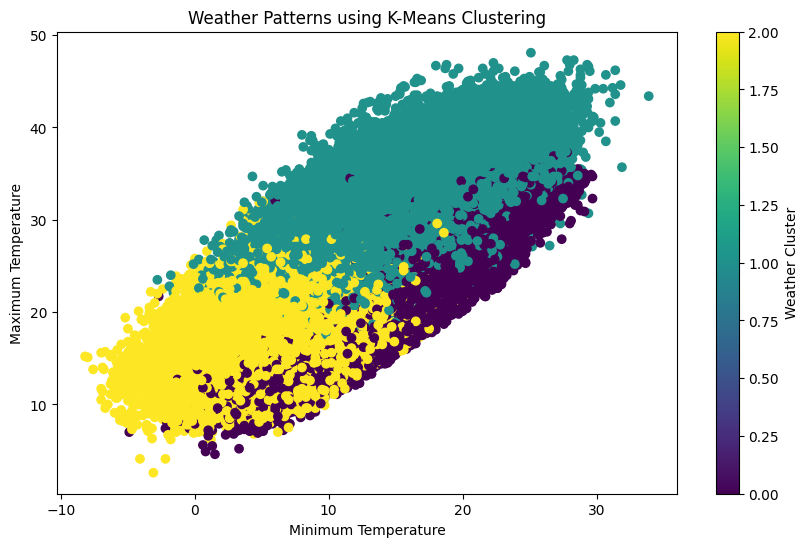

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["MinTemp"],
    df["MaxTemp"],
    c=df["Weather_Cluster"]
)

plt.xlabel("Minimum Temperature")
plt.ylabel("Maximum Temperature")
plt.title("Weather Patterns using K-Means Clustering")

plt.colorbar(label="Weather Cluster")

plt.show()

In [16]:
best_classification = classification_df.loc[
    classification_df["F1-Score"].idxmax()
]

print("Classification model based on highest F1-Score:")
print(best_classification["Model"])

print("\nAccuracy:", round(best_classification["Accuracy"], 4))
print("Precision:", round(best_classification["Precision"], 4))
print("Recall:", round(best_classification["Recall"], 4))
print("F1-Score:", round(best_classification["F1-Score"], 4))

best_regression = regression_df.loc[
    regression_df["R2 Score"].idxmax()
]

print("Regression model based on highest R2 Score:")
print(best_regression["Model"])

print("\nMAE:", round(best_regression["MAE"], 4))
print("RMSE:", round(best_regression["RMSE"], 4))
print("R2 Score:", round(best_regression["R2 Score"], 4))

Classification model based on highest F1-Score:
Random Forest

Accuracy: 0.8489
Precision: 0.7368
Recall: 0.4921
F1-Score: 0.5901
Regression model based on highest R2 Score:
Random Forest

MAE: 1.9187
RMSE: 6.6192
R2 Score: 0.3573
